In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from src.metapopulation import Metapopulation

CONFIG = os.path.join(os.path.dirname(os.path.abspath("__file__")), "distance_delays.yaml")
TOPOLOGIES = ['line', 'full', 'ring', 'lattice']
VELOCITIES = [1, 6]

In [2]:
def run(topology, v):
    model = Metapopulation()
    model.load_config(CONFIG)
    model.create_network(params={'topology': topology})
    if v == 1:
        model.create_delay_matrix(mode='distance', v=v, target_mean_rho=10.0)
    else:
        model.create_delay_matrix(mode='distance', v=v)
    model.initialise_model()
    model.run_simulation()
    return model

In [3]:
def synchrony_index(trajectories):
    """
    Mean over time of variance across nodes.
    Low value = high synchrony.
    Computed on excitatory population only.
    """
    E = trajectories[0]  # (N, T)
    return float(np.mean(np.var(E, axis=0)))


def dominant_frequency(trajectories, dt):
    """
    Mean dominant frequency across nodes.
    Computed on excitatory population via FFT.
    Ignores DC component (zero frequency).
    """
    E = trajectories[0]  # (N, T)
    freqs = np.fft.rfftfreq(E.shape[1], d=dt)
    fft_power = np.abs(np.fft.rfft(E, axis=1))
    # Ignore DC component by zeroing out index 0
    fft_power[:, 0] = 0
    # Mean power across nodes
    fft_mean = np.mean(fft_power, axis=0)
    return float(freqs[np.argmax(fft_mean)])


def mean_delay(delay_matrix):
    N = delay_matrix.shape[0]
    mask = ~np.eye(N, dtype=bool)
    return float(np.mean(delay_matrix[mask]))

In [4]:
results = {}
for topology in TOPOLOGIES:
    for v in VELOCITIES:
        print(f"Running {topology}, v={v}...")
        m = run(topology, v)
        D = m.model.params['rho']
        results[(topology, v)] = {
            'time': m.model.time_array,
            'trajectories': m.model.trajectories,
            'mean_delay': mean_delay(D),
            'synchrony': synchrony_index(m.model.trajectories[:, :, m.model.time_array >= 20]),
            'dom_freq': dominant_frequency(m.model.trajectories[:, :, m.model.time_array >= 20], m.model.dt)
        }
print("All runs complete.")

Running line, v=1...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  1.76470588,  3.52941176,  5.29411765,  7.05882353,
         8.82352941, 10.58823529, 12.35294118, 14.11764706, 15.88235294,
        17.64705882, 19.41176471, 21.17647059, 22.94117647, 24.70588235,
        26.47058824],
       [ 1.76470588,  0.        ,  1.76470588,  3.52941176,  5.29411765,
         7.05882353,  8.82352941, 10.58823529, 12.35294118, 14.11764706,
        15.88235294, 17.64705882, 19.41176471, 21.17647059, 22.94117647,
        24.70588235],
       [ 3.52941176,  1.76470588,  0.        ,  1.76470588,  3.52941176,
         5.29411765,  7.05882353,  8.82352941, 10.58823529, 12.35294118,
        14.11764706, 15.88235294, 17.64705882, 19.41176471, 21.17647059,
        22.94117647],
       [ 5.29411765,  3.52941176,  1.76470588,  0.        ,  1.76470588,
         3.52941176,  5.29411765,  7.05882353,  8.82352941,

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Running line, v=6...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[0.        , 0.16666667, 0.33333333, 0.5       , 0.66666667,
        0.83333333, 1.        , 1.16666667, 1.33333333, 1.5       ,
        1.66666667, 1.83333333, 2.        , 2.16666667, 2.33333333,
        2.5       ],
       [0.16666667, 0.        , 0.16666667, 0.33333333, 0.5       ,
        0.66666667, 0.83333333, 1.        , 1.16666667, 1.33333333,
        1.5       , 1.66666667, 1.83333333, 2.        , 2.16666667,
        2.33333333],
       [0.33333333, 0.16666667, 0.        , 0.16666667, 0.33333333,
        0.5       , 0.66666667, 0.83333333, 1.        , 1.16666667,
        1.33333333, 1.5       , 1.66666667, 1.83333333, 2.        ,
        2.16666667],
       [0.5       , 0.33333333, 0.16666667, 0.        , 0.16666667,
        0.33333333, 0.5       , 0.66666667, 0.83333333, 1.        ,
      

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Running full, v=1...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.

...

Using default integration parameters.
Running lattice, v=1...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.  ,  3.75,  7.5 , 11.25,  3.75,  7.5 , 11.25, 15.  ,  7.5 ,
        11.25, 15.  , 18.75, 11.25, 15.  , 18.75, 22.5 ],
       [ 3.75,  0.  ,  3.75,  7.5 ,  7.5 ,  3.75,  7.5 , 11.25, 11.25,
         7.5 , 11.25, 15.  , 15.  , 11.25, 15.  , 18.75],
       [ 7.5 ,  3.75,  0.  ,  3.75, 11.25,  7.5 ,  3.75,  7.5 , 15.  ,
        11.25,  7.5 , 11.25, 18.75, 15.  , 11.25, 15.  ],
       [11.25,  7.5 ,  3.75,  0.  , 15.  , 11.25,  7.5 ,  3.75, 18.75,
        15.  , 11.25,  7.5 , 22.5 , 18.75, 15.  , 11.25],
       [ 3.75,  7.5 , 11.25, 15.  ,  0.  ,  3.75,  7.5 , 11.25,  3.75,
         7.5 , 11.25, 15.  ,  7.5 , 11.25, 15.  , 18.75],
       [ 7.5 ,  3.75,  7.5 , 11.25,  3.75,  0.  ,  3.75,  7.5 ,  7.5 ,
         3.75,  7.5 , 11.25, 11.25,  7.5 , 11.25, 15.  ],
       [11.25,  7.5 ,  3.75,  7.5 ,  7.5

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Running lattice, v=6...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[0.        , 0.16666667, 0.33333333, 0.5       , 0.16666667,
        0.33333333, 0.5       , 0.66666667, 0.33333333, 0.5       ,
        0.66666667, 0.83333333, 0.5       , 0.66666667, 0.83333333,
        1.        ],
       [0.16666667, 0.        , 0.16666667, 0.33333333, 0.33333333,
        0.16666667, 0.33333333, 0.5       , 0.5       , 0.33333333,
        0.5       , 0.66666667, 0.66666667, 0.5       , 0.66666667,
        0.83333333],
       [0.33333333, 0.16666667, 0.        , 0.16666667, 0.5       ,
        0.33333333, 0.16666667, 0.33333333, 0.66666667, 0.5       ,
        0.33333333, 0.5       , 0.83333333, 0.66666667, 0.5       ,
        0.66666667],
       [0.5       , 0.33333333, 0.16666667, 0.        , 0.66666667,
        0.5       , 0.33333333, 0.16666667, 0.83333333, 0.66666667,
   

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
All runs complete.


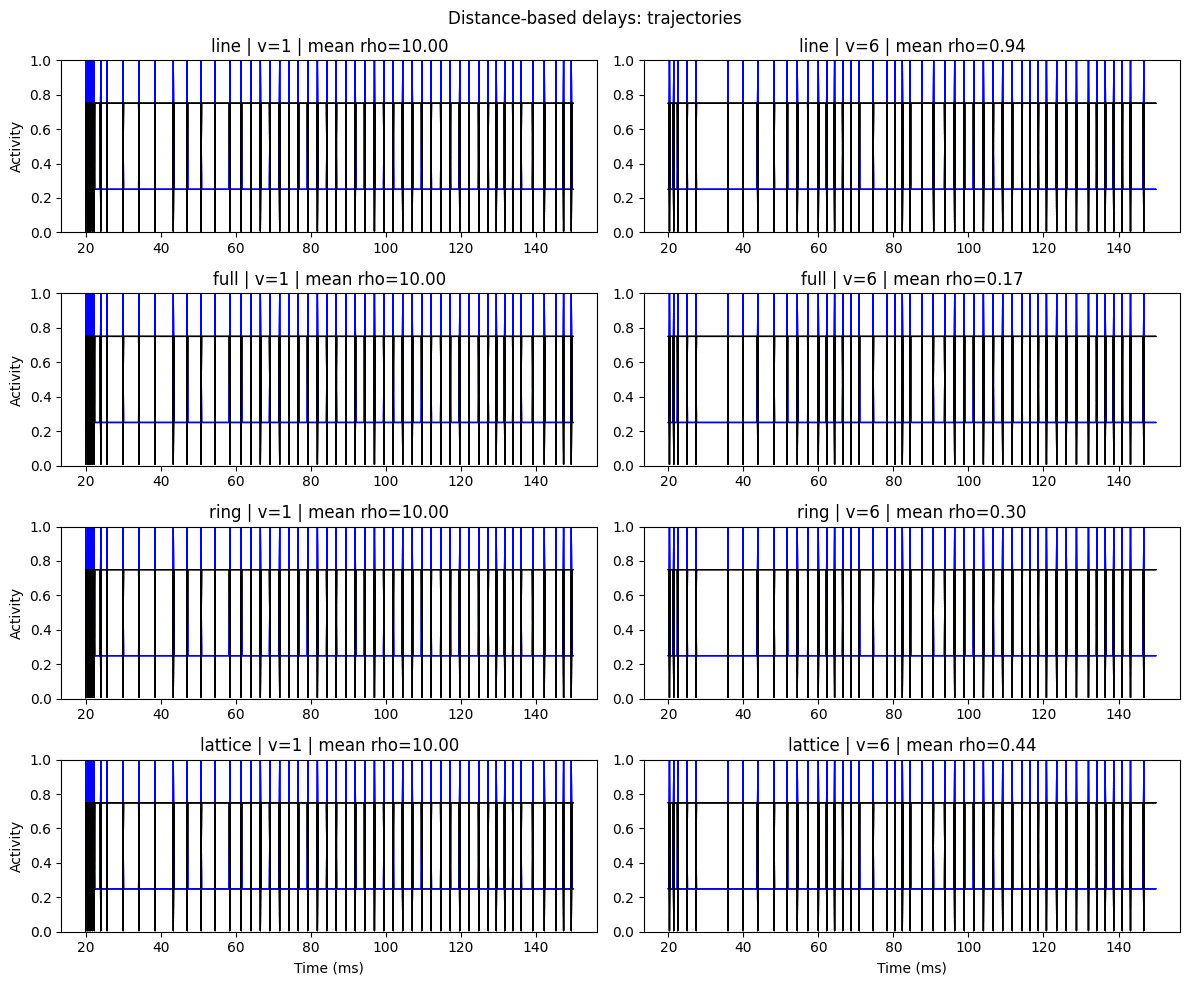

In [5]:
fig, axes = plt.subplots(len(TOPOLOGIES), len(VELOCITIES), figsize=(12, 10))
fig.suptitle("Distance-based delays: trajectories")

for i, topology in enumerate(TOPOLOGIES):
    for j, v in enumerate(VELOCITIES):
        r = results[(topology, v)]
        ax = axes[i, j]
        t = r['time']
        mask = t >= 20
        ax.plot(t[mask], r['trajectories'][0][:, mask].T, color='blue', alpha=0.5, linewidth=0.8)
        ax.plot(t[mask], r['trajectories'][1][:, mask].T, color='black', alpha=0.5, linewidth=0.8)
        ax.set_title(f"{topology} | v={v} | mean rho={r['mean_delay']:.2f}")
        ax.set_ylim(0, 1)
        if i == len(TOPOLOGIES) - 1:
            ax.set_xlabel("Time (ms)")
        if j == 0:
            ax.set_ylabel("Activity")

plt.tight_layout()
plt.savefig("distance_delays_trajectories.png", dpi=150)
plt.show()

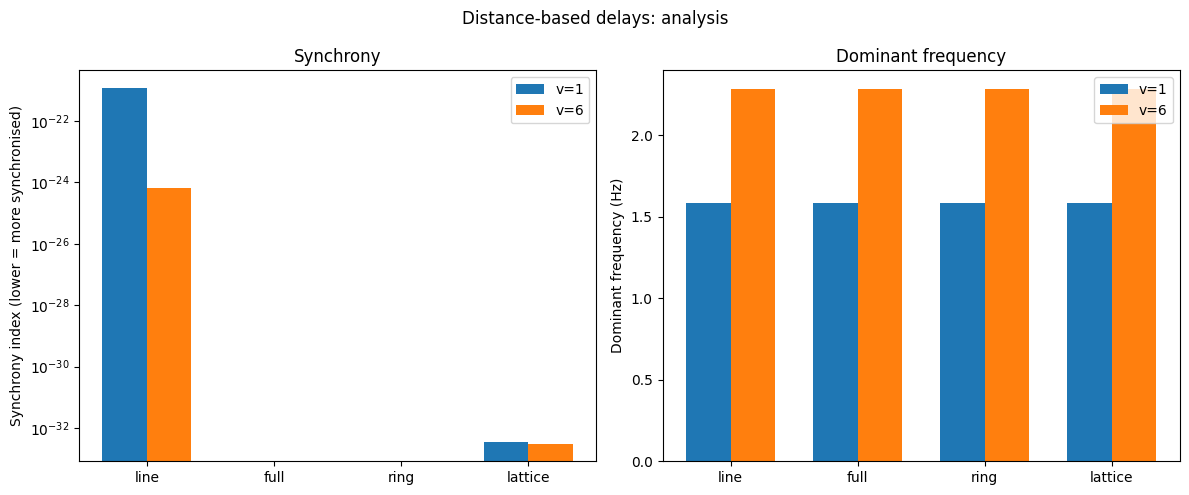

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distance-based delays: analysis")

x = np.arange(len(TOPOLOGIES))
width = 0.35

for k, v in enumerate(VELOCITIES):
    sync = [results[(t, v)]['synchrony'] for t in TOPOLOGIES]
    freq = [results[(t, v)]['dom_freq'] for t in TOPOLOGIES]
    axes[0].bar(x + k*width, sync, width, label=f"v={v}")
    axes[1].bar(x + k*width, freq, width, label=f"v={v}")

axes[0].set_xticks(x + width/2)
axes[0].set_xticklabels(TOPOLOGIES)
axes[0].set_ylabel("Synchrony index (lower = more synchronised)")
axes[0].set_title("Synchrony")
axes[0].set_yscale('log')
axes[0].legend()

axes[1].set_xticks(x + width/2)
axes[1].set_xticklabels(TOPOLOGIES)
axes[1].set_ylabel("Dominant frequency (Hz)")
axes[1].set_title("Dominant frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("distance_delays_analysis.png", dpi=150)
plt.show()

In [7]:
print(f"{'Topology':<10} {'v':<5} {'Mean delay':<12} {'Synchrony':<15} {'Dom freq (Hz)':<10}")
print("-" * 55)
for topology in TOPOLOGIES:
    for v in VELOCITIES:
        r = results[(topology, v)]
        print(f"{topology:<10} {v:<5} {r['mean_delay']:<12.3f} {r['synchrony']:<15.3e} {r['dom_freq']:<10.3f}")

Topology   v     Mean delay   Synchrony       Dom freq (Hz)
-------------------------------------------------------
line       1     10.000       1.172e-21       1.585     
line       6     0.944        6.724e-25       2.285     
full       1     10.000       0.000e+00       1.585     
full       6     0.167        0.000e+00       2.285     
ring       1     10.000       0.000e+00       1.585     
ring       6     0.300        0.000e+00       2.285     
lattice    1     10.000       3.451e-33       1.585     
lattice    6     0.444        3.119e-33       2.285     


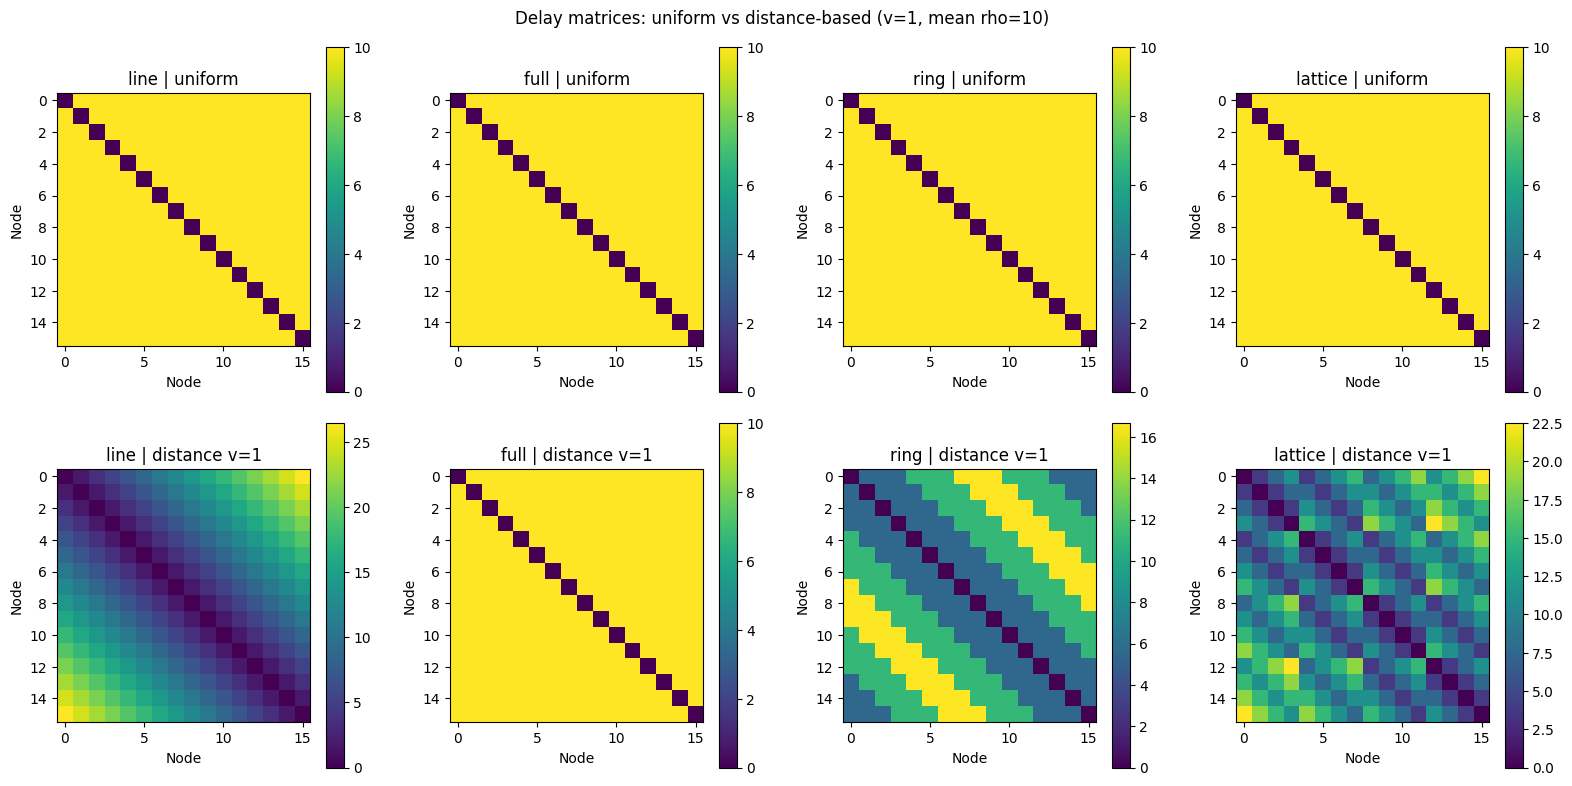

In [8]:
# delay matrix heatmap

fig, axes = plt.subplots(2, len(TOPOLOGIES), figsize=(16, 8))
fig.suptitle("Delay matrices: uniform vs distance-based (v=1, mean rho=10)")

from src.delays import uniform_delay_matrix, distance_delay_matrix

for i, topology in enumerate(TOPOLOGIES):
    # Get network for this topology
    m_temp = Metapopulation()
    m_temp.load_config(CONFIG)
    m_temp.create_network(params={'topology': topology})
    
    # Uniform delay matrix
    D_uniform = uniform_delay_matrix(m_temp.network, rho=10.0)
    # Distance delay matrix
    D_distance = distance_delay_matrix(m_temp.network, v=1, target_mean_rho=10.0)
    
    im0 = axes[0, i].imshow(D_uniform, cmap='viridis')
    axes[0, i].set_title(f"{topology} | uniform")
    axes[0, i].set_xlabel("Node")
    axes[0, i].set_ylabel("Node")
    plt.colorbar(im0, ax=axes[0, i])
    
    im1 = axes[1, i].imshow(D_distance, cmap='viridis')
    axes[1, i].set_title(f"{topology} | distance v=1")
    axes[1, i].set_xlabel("Node")
    axes[1, i].set_ylabel("Node")
    plt.colorbar(im1, ax=axes[1, i])

plt.tight_layout()
plt.savefig("delay_matrices.png", dpi=150)
plt.show()

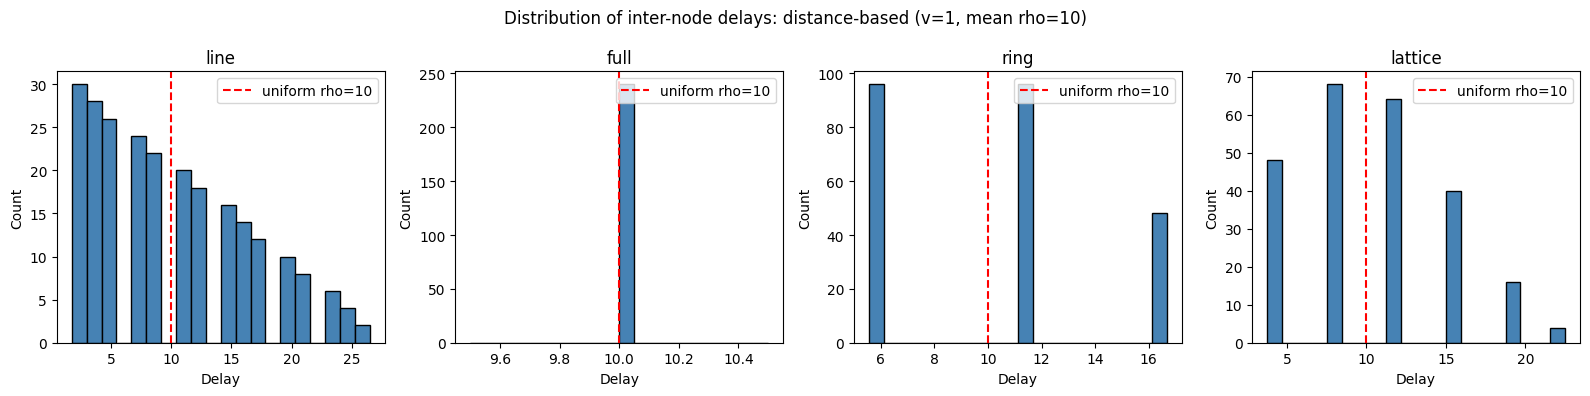

In [9]:
fig, axes = plt.subplots(1, len(TOPOLOGIES), figsize=(16, 4))
fig.suptitle("Distribution of inter-node delays: distance-based (v=1, mean rho=10)")

for i, topology in enumerate(TOPOLOGIES):
    m_temp = Metapopulation()
    m_temp.load_config(CONFIG)
    m_temp.create_network(params={'topology': topology})
    D = distance_delay_matrix(m_temp.network, v=1, target_mean_rho=10.0)
    
    N = m_temp.network.N
    mask = ~np.eye(N, dtype=bool)
    delays = D[mask].flatten()
    
    axes[i].hist(delays, bins=20, color='steelblue', edgecolor='black')
    axes[i].axvline(x=10, color='red', linestyle='--', label='uniform rho=10')
    axes[i].set_title(topology)
    axes[i].set_xlabel("Delay")
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.tight_layout()
plt.savefig("delay_distributions.png", dpi=150)
plt.show()


In [10]:
def compute_phase_difference(trajectory, dt, reference_node=0):
    """
    Compute mean phase difference between reference node and all others.
    Uses FFT to find dominant frequency then compute phase at that frequency.
    """
    E = trajectory[0]  # (N, T)
    N = E.shape[0]
    
    freqs = np.fft.rfftfreq(E.shape[1], d=dt)
    fft_vals = np.fft.rfft(E, axis=1)
    
    # Find dominant frequency from mean power (ignore DC)
    mean_power = np.mean(np.abs(fft_vals), axis=0)
    mean_power[0] = 0
    dom_idx = np.argmax(mean_power)
    
    # Phase at dominant frequency for each node
    phases = np.angle(fft_vals[:, dom_idx])
    
    # Phase difference relative to reference node
    phase_diffs = np.abs(phases - phases[reference_node])
    # Wrap to [0, pi]
    phase_diffs = np.where(phase_diffs > np.pi, 2*np.pi - phase_diffs, phase_diffs)
    
    return phase_diffs